# MuJoCo Simulation — Results Analysis

| Variable | File | Shape | Plane | Radius | Period |
|---|---|---|---|---|---|
| `circle_xy` | sim_20260526_145251 | circle | XY | 0.40 m | 20 s |
| `circle_yz` | sim_20260526_150117 | circle | YZ | 0.40 m | 20 s |
| `rectangle_yz` | sim_20260526_150448 | rectangle | YZ | 0.40 m | 20 s |

Historical logs (fixed target — `arc_start_time` never initialized bug):

| Variable | File | Duration |
|---|---|---|
| `arc_fixed_10s` | sim_20260416_074644 | 10 s |
| `arc_fixed_20s_a` | sim_20260416_083352 | 20 s |
| `arc_fixed_long_256s` | sim_20260416_083611 | 256 s |
| `arc_fixed_short_interrupted` | sim_20260416_181107 | 2.3 s |
| `arc_fixed_6s` | sim_20260416_181228 | 6.7 s |
| `arc_fixed_157s` | sim_20260416_184641 | 157 s |
| `arc_fixed_40s_a` | sim_20260519_095803 | 40 s |
| `arc_fixed_20s_b` | sim_20260519_095957 | 20 s |
| `arc_fixed_40s_b` | sim_20260519_100116 | 40 s |

In [86]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

LOG_DIR = Path("logs")

def load(filename):
    return pd.read_csv(LOG_DIR / filename)

# ── Today's tests (moving trajectory) ────────────────────────────────────────
circle_xy      = load("sim_20260526_145251.csv")  # circle, XY plane, r=0.40 m
circle_yz      = load("sim_20260526_150117.csv")  # circle, YZ plane, r=0.40 m
rectangle_yz   = load("sim_20260526_150448.csv")  # rectangle, YZ plane, r=0.40 m

# ── Historical logs (fixed target) ───────────────────────────────────────────
arc_fixed_10s               = load("sim_20260416_074644.csv")
arc_fixed_20s_a             = load("sim_20260416_083352.csv")
arc_fixed_long_256s         = load("sim_20260416_083611.csv")
arc_fixed_short_interrupted = load("sim_20260416_181107.csv")
arc_fixed_6s                = load("sim_20260416_181228.csv")
arc_fixed_157s              = load("sim_20260416_184641.csv")
arc_fixed_40s_a             = load("sim_20260519_095803.csv")
arc_fixed_20s_b             = load("sim_20260519_095957.csv")
arc_fixed_40s_b             = load("sim_20260519_100116.csv")

today_tests = {
    "circle_xy":    circle_xy,
    "circle_yz":    circle_yz,
    "rectangle_yz": rectangle_yz,
}
historic_tests = {
    "arc_fixed_10s":               arc_fixed_10s,
    "arc_fixed_20s_a":             arc_fixed_20s_a,
    "arc_fixed_long_256s":         arc_fixed_long_256s,
    "arc_fixed_short_interrupted": arc_fixed_short_interrupted,
    "arc_fixed_6s":                arc_fixed_6s,
    "arc_fixed_157s":              arc_fixed_157s,
    "arc_fixed_40s_a":             arc_fixed_40s_a,
    "arc_fixed_20s_b":             arc_fixed_20s_b,
    "arc_fixed_40s_b":             arc_fixed_40s_b,
}

COLORS = {"circle_xy": "steelblue", "circle_yz": "seagreen", "rectangle_yz": "darkorange"}
TENSION_DESIRED = 10.0

print("Loaded tests:")
for name, df in {**today_tests, **historic_tests}.items():
    print(f"  {name:35s}  {len(df):5d} samples  duration={df['time'].iloc[-1]:.1f}s")

Loaded tests:
  circle_xy                             1136 samples  duration=26.0s
  circle_yz                             1486 samples  duration=33.0s
  rectangle_yz                          1200 samples  duration=27.3s
  arc_fixed_10s                          500 samples  duration=10.0s
  arc_fixed_20s_a                       1000 samples  duration=20.0s
  arc_fixed_long_256s                  14111 samples  duration=256.4s
  arc_fixed_short_interrupted            832 samples  duration=2.3s
  arc_fixed_6s                           169 samples  duration=6.7s
  arc_fixed_157s                        7700 samples  duration=157.3s
  arc_fixed_40s_a                       1833 samples  duration=40.0s
  arc_fixed_20s_b                        862 samples  duration=20.6s
  arc_fixed_40s_b                       1833 samples  duration=40.0s


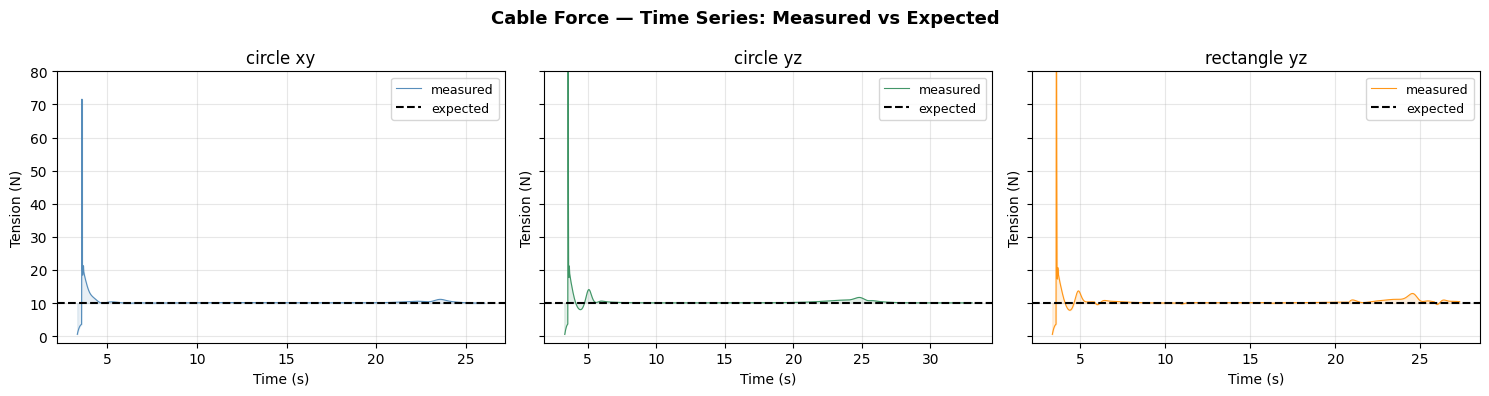

In [88]:
# Time-series version: Measured vs Expected on the same plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
fig.suptitle("Cable Force — Time Series: Measured vs Expected", fontsize=13, fontweight="bold")

for ax, (name, df) in zip(axes, today_tests.items()):
    ax.plot(df["time"], df["tension_N"], color=COLORS[name], linewidth=0.8,
            alpha=0.9, label="measured")
    ax.axhline(TENSION_DESIRED, color="black", linestyle="--", linewidth=1.5, label="expected")
    ax.fill_between(df["time"], df["tension_N"], TENSION_DESIRED,
                    alpha=0.12, color=COLORS[name])
    ax.set_title(name.replace("_", " "))
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Tension (N)")
    ax.set_ylim(-2, 80)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2 — Trajectory: Measured vs Expected

Expected trajectory (target) vs measured trajectory (actual EE) in the active plane of each test.

> **Note:** The CSV only stores `tgt_x` and `tgt_y` (first two components of the 3D target).  
> For YZ tests, `tgt_y` is the Y component of the target; the Z component was not logged.  
> The actual EE has measured Z (`ee_z`), so `ee_y vs ee_z` is used for the EE path in YZ tests.

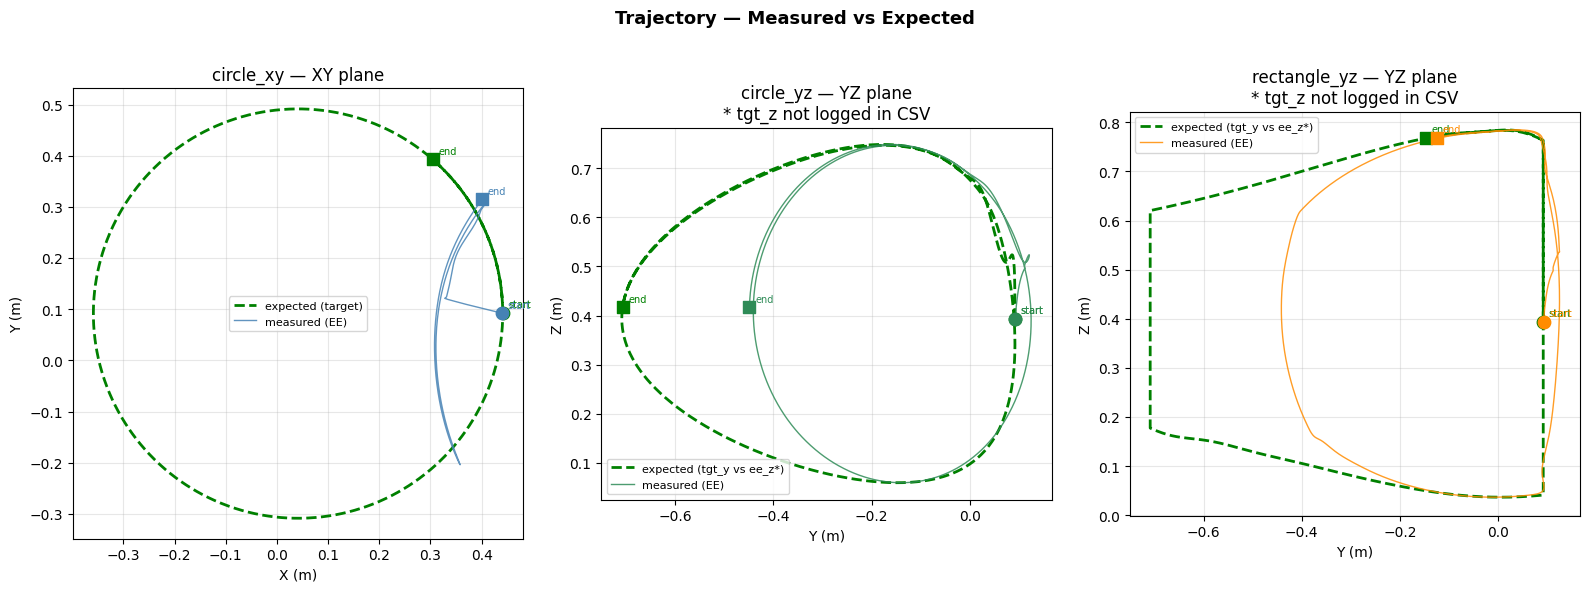

In [89]:
fig = plt.figure(figsize=(16, 6))
fig.suptitle("Trajectory — Measured vs Expected", fontsize=13, fontweight="bold")

def mark_start_end(ax, x_series, y_series, color):
    ax.scatter(x_series.iloc[0],  y_series.iloc[0],  marker="o", s=80,
               color=color, zorder=6, label="_nolegend_")
    ax.scatter(x_series.iloc[-1], y_series.iloc[-1], marker="s", s=80,
               color=color, zorder=6, label="_nolegend_")
    ax.annotate("start", (x_series.iloc[0],  y_series.iloc[0]),
                fontsize=7, color=color, xytext=(4, 4), textcoords="offset points")
    ax.annotate("end",   (x_series.iloc[-1], y_series.iloc[-1]),
                fontsize=7, color=color, xytext=(4, 4), textcoords="offset points")

# ── circle_xy (XY plane) ────────────────────────────────────────────────────
ax1 = fig.add_subplot(1, 3, 1)
ax1.plot(circle_xy["tgt_x"], circle_xy["tgt_y"],
         "g--", linewidth=2.0, label="expected (target)")
ax1.plot(circle_xy["ee_x"],  circle_xy["ee_y"],
         color=COLORS["circle_xy"], linewidth=1.0, alpha=0.85, label="measured (EE)")
mark_start_end(ax1, circle_xy["tgt_x"], circle_xy["tgt_y"], "green")
mark_start_end(ax1, circle_xy["ee_x"],  circle_xy["ee_y"],  COLORS["circle_xy"])
ax1.set_xlabel("X (m)"); ax1.set_ylabel("Y (m)")
ax1.set_title("circle_xy — XY plane")
ax1.legend(fontsize=8); ax1.set_aspect("equal"); ax1.grid(True, alpha=0.3)

# ── circle_yz (YZ plane) ────────────────────────────────────────────────────
ax2 = fig.add_subplot(1, 3, 2)
ax2.plot(circle_yz["tgt_y"], circle_yz["ee_z"],
         "g--", linewidth=2.0, label="expected (tgt_y vs ee_z*)")
ax2.plot(circle_yz["ee_y"],  circle_yz["ee_z"],
         color=COLORS["circle_yz"], linewidth=1.0, alpha=0.85, label="measured (EE)")
mark_start_end(ax2, circle_yz["tgt_y"], circle_yz["ee_z"], "green")
mark_start_end(ax2, circle_yz["ee_y"],  circle_yz["ee_z"], COLORS["circle_yz"])
ax2.set_xlabel("Y (m)"); ax2.set_ylabel("Z (m)")
ax2.set_title("circle_yz — YZ plane\n* tgt_z not logged in CSV")
ax2.legend(fontsize=8); ax2.set_aspect("equal"); ax2.grid(True, alpha=0.3)

# ── rectangle_yz (YZ plane) ─────────────────────────────────────────────────
ax3 = fig.add_subplot(1, 3, 3)
ax3.plot(rectangle_yz["tgt_y"], rectangle_yz["ee_z"],
         "g--", linewidth=2.0, label="expected (tgt_y vs ee_z*)")
ax3.plot(rectangle_yz["ee_y"],  rectangle_yz["ee_z"],
         color=COLORS["rectangle_yz"], linewidth=1.0, alpha=0.85, label="measured (EE)")
mark_start_end(ax3, rectangle_yz["tgt_y"], rectangle_yz["ee_z"], "green")
mark_start_end(ax3, rectangle_yz["ee_y"],  rectangle_yz["ee_z"], COLORS["rectangle_yz"])
ax3.set_xlabel("Y (m)"); ax3.set_ylabel("Z (m)")
ax3.set_title("rectangle_yz — YZ plane\n* tgt_z not logged in CSV")
ax3.legend(fontsize=8); ax3.set_aspect("equal"); ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3 — Cable tension: all tests

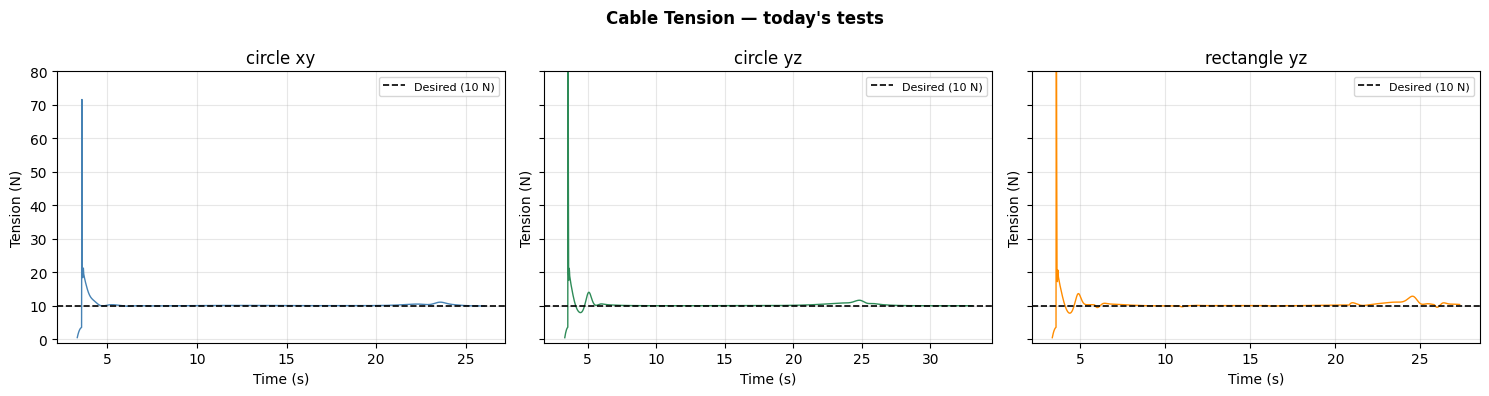

In [91]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
fig.suptitle("Cable Tension — today's tests", fontweight="bold")

for ax, (name, df) in zip(axes, today_tests.items()):
    ax.plot(df["time"], df["tension_N"], color=COLORS[name], linewidth=1.0)
    ax.axhline(TENSION_DESIRED, color="black", linestyle="--", linewidth=1.2, label="Desired (10 N)")
    ax.set_title(name.replace("_", " "))
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Tension (N)")
    ax.set_ylim(-1, 80)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4 — Cable distance and taut state

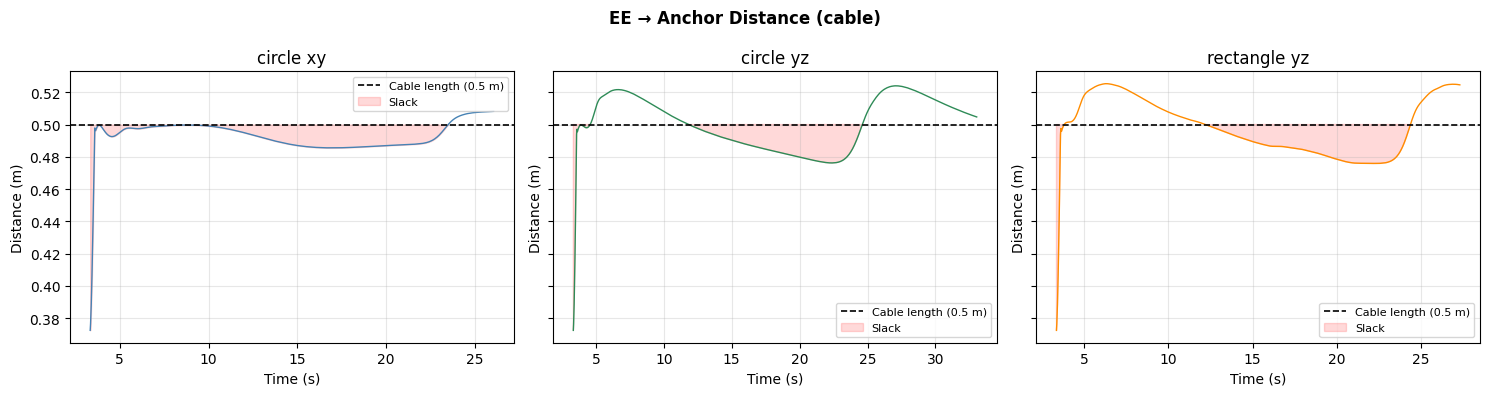

In [92]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
fig.suptitle("EE → Anchor Distance (cable)", fontweight="bold")

for ax, (name, df) in zip(axes, today_tests.items()):
    ax.plot(df["time"], df["cable_dist_m"], color=COLORS[name], linewidth=1.0)
    ax.axhline(0.50, color="black", linestyle="--", linewidth=1.2, label="Cable length (0.5 m)")
    ax.fill_between(df["time"], df["cable_dist_m"], 0.50,
                    where=df["cable_dist_m"] < 0.50, alpha=0.15, color="red", label="Slack")
    ax.set_title(name.replace("_", " "))
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Distance (m)")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5 — Summary statistics

In [93]:
RAMP_SKIP_S = 5.0  # ignore first 5 s (setpoint ramp-up)

rows = []
for name, df in today_tests.items():
    task = df[(df["cable_taut"] == 1) & (df["time"] >= RAMP_SKIP_S)].copy()
    rows.append({
        "test":                  name,
        "duration (s)":          round(df["time"].iloc[-1], 1),
        "samples (t≥5s)":        len(task),
        "tension mean (N)":      round(task["tension_N"].mean(), 2),
        "tension std (N)":       round(task["tension_N"].std(), 2),
        "tension bias (N)":      round(task["tension_N"].mean() - TENSION_DESIRED, 2),
        "traj. error mean (m)":  round(task["pos_error_m"].mean(), 4),
        "traj. error max (m)":   round(task["pos_error_m"].max(), 4),
    })

pd.DataFrame(rows).set_index("test")

,duration (s),samples (t≥5s),tension mean (N),tension std (N),tension bias (N),traj. error mean (m),traj. error max (m)
test,,,,,,,
circle_xy,26.0,1053,10.15,0.21,0.15,0.3434,0.6724
circle_yz,33.0,1403,10.27,0.48,0.27,0.1536,0.3007
rectangle_yz,27.3,1117,10.35,0.51,0.35,0.1635,0.4098


## 7 — Real Robot Results

| Variable | File | Shape | Plane | Radius | Duration |
|---|---|---|---|---|---|
| `real_circle_xy_r005` | tension_20260526_112845 | circle | XY | 0.05 m | 38.8 s |
| `real_circle_xy_r020` | tension_20260526_114001 | circle | XY | 0.20 m | 43.4 s |
| `real_circle_xy_r040` | tension_20260526_114519 | circle | XY | 0.40 m | 19.7 s |
| `real_rect_xy_r010` | tension_20260526_115522 | rectangle | XY | 0.2 m | 25.5 s |
| `real_triangle_xy_r010` | tension_20260526_120807 | triangle | XY | 0.10 m | 43.4 s |
| `real_circle_xz_r010` | tension_20260526_121804 | circle | XZ | 0.10 m | 34.8 s |
| `real_circle_xz_cabo` | tension_20260526_122308 | ? | XZ | 0.10 m | 19.9 s |

Columns: `t_sec`, `T_des_target_N`, `T_des_active_N`, `T_meas_N`,
`ee_x_m`, `ee_y_m`, `ee_z_m`, `ee_des_x_m`, `ee_des_y_m`, `ee_des_z_m`

In [95]:
REAL_LOG_DIR = Path("/home/eduardo/franka_ws/logs")

def load_real(filename):
    df = pd.read_csv(REAL_LOG_DIR / filename)
    df["time"] = df["t_sec"] - df["t_sec"].iloc[0]
    df["pos_error_m"] = np.sqrt(
        (df["ee_x_m"] - df["ee_des_x_m"])**2 +
        (df["ee_y_m"] - df["ee_des_y_m"])**2 +
        (df["ee_z_m"] - df["ee_des_z_m"])**2
    )
    return df

real_circle_xy_r005  = load_real("tension_20260526_112845.csv")
real_circle_xy_r020  = load_real("tension_20260526_114001.csv")
real_circle_xy_r040  = load_real("tension_20260526_114519.csv")
real_rectangle_xy_r010  = load_real("tension_20260526_115522.csv")
real_triangle_xy_r010 = load_real("tension_20260526_120807.csv")
real_circle_xz_r010       = load_real("tension_20260526_121804.csv")
real_circle_xz_cabo       = load_real("tension_20260526_122308.csv")

real_tests = {
    "circle_xy_r005":   real_circle_xy_r005,
    "circle_xy_r020":   real_circle_xy_r020,
    "circle_xy_r040":   real_circle_xy_r040,
    "rectangle_xy_r010":   real_rectangle_xy_r010,
    "triangle_xy_r010": real_triangle_xy_r010,
    "circle_xz_r010":        real_circle_xz_r010,
    "circle_xz_cabo":        real_circle_xz_cabo,
}
REAL_TENSION_DESIRED = 10.0

print("Loaded real robot tests:")
for name, df in real_tests.items():
    print(f"  {name:25s}  {len(df):5d} samples  duration={df['time'].iloc[-1]:.1f}s  T_meas_mean={df['T_meas_N'].mean():.2f}N")


Loaded real robot tests:
  circle_xy_r005              3885 samples  duration=38.8s  T_meas_mean=7.25N
  circle_xy_r020              4340 samples  duration=43.4s  T_meas_mean=7.55N
  circle_xy_r040              1976 samples  duration=19.7s  T_meas_mean=6.45N
  rectangle_xy_r010           2548 samples  duration=25.5s  T_meas_mean=6.71N
  triangle_xy_r010            4338 samples  duration=43.4s  T_meas_mean=7.23N
  circle_xz_r010              3485 samples  duration=34.8s  T_meas_mean=6.99N
  circle_xz_cabo              1989 samples  duration=19.9s  T_meas_mean=6.45N


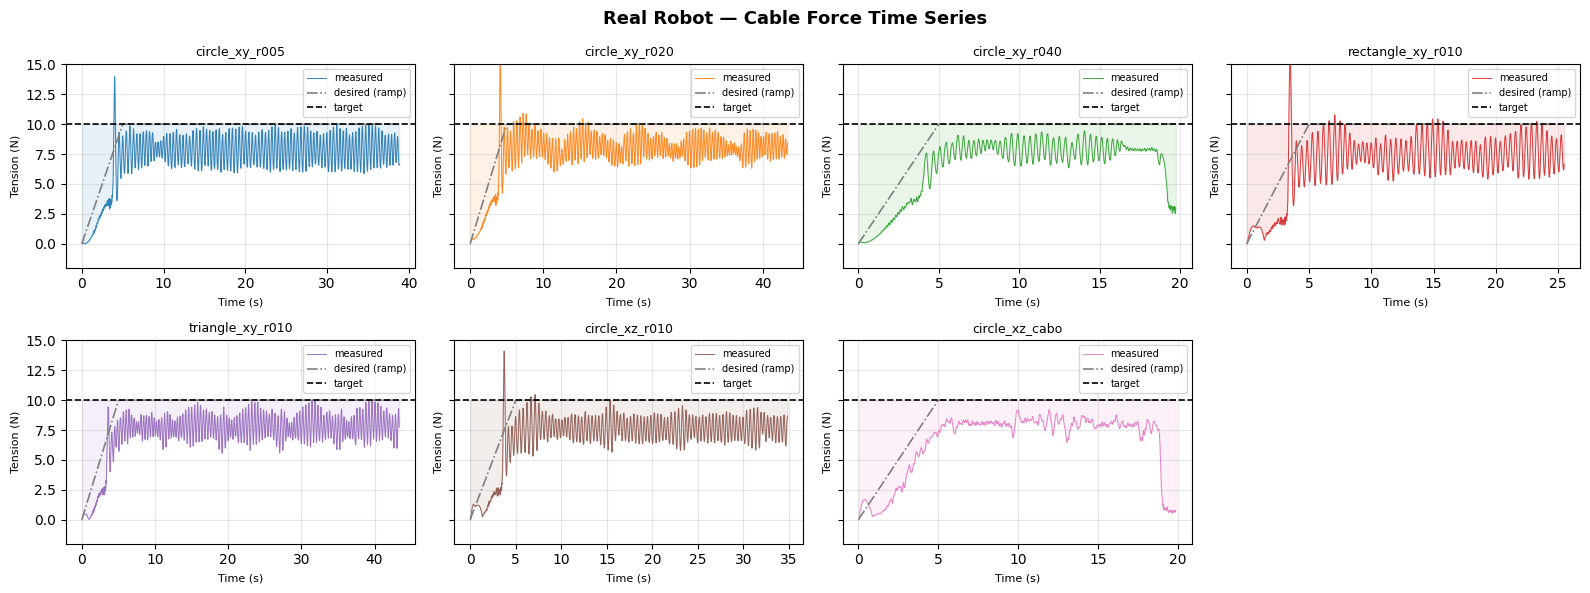

In [97]:
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3), sharey=True)
fig.suptitle("Real Robot — Cable Force Time Series", fontsize=13, fontweight="bold")
axes = axes.flatten()

for i, (name, df) in enumerate(real_tests.items()):
    ax = axes[i]
    ax.plot(df["time"], df["T_meas_N"], linewidth=0.7, alpha=0.9, color=cmap[i], label="measured")
    ax.plot(df["time"], df["T_des_active_N"], linewidth=1.2, linestyle="-.",
            color="gray", label="desired (ramp)")
    ax.axhline(REAL_TENSION_DESIRED, color="black", linestyle="--", linewidth=1.2, label="target")
    ax.fill_between(df["time"], df["T_meas_N"], REAL_TENSION_DESIRED,
                    alpha=0.1, color=cmap[i])
    ax.set_title(name, fontsize=9)
    ax.set_xlabel("Time (s)", fontsize=8)
    ax.set_ylabel("Tension (N)", fontsize=8)
    ax.set_ylim(-2, max(df["T_meas_N"].max() * 1.1, 15))
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


### 7.2 — Trajectory: Measured vs Expected

2D path overlay (EE actual vs EE desired) in the active plane of each test.

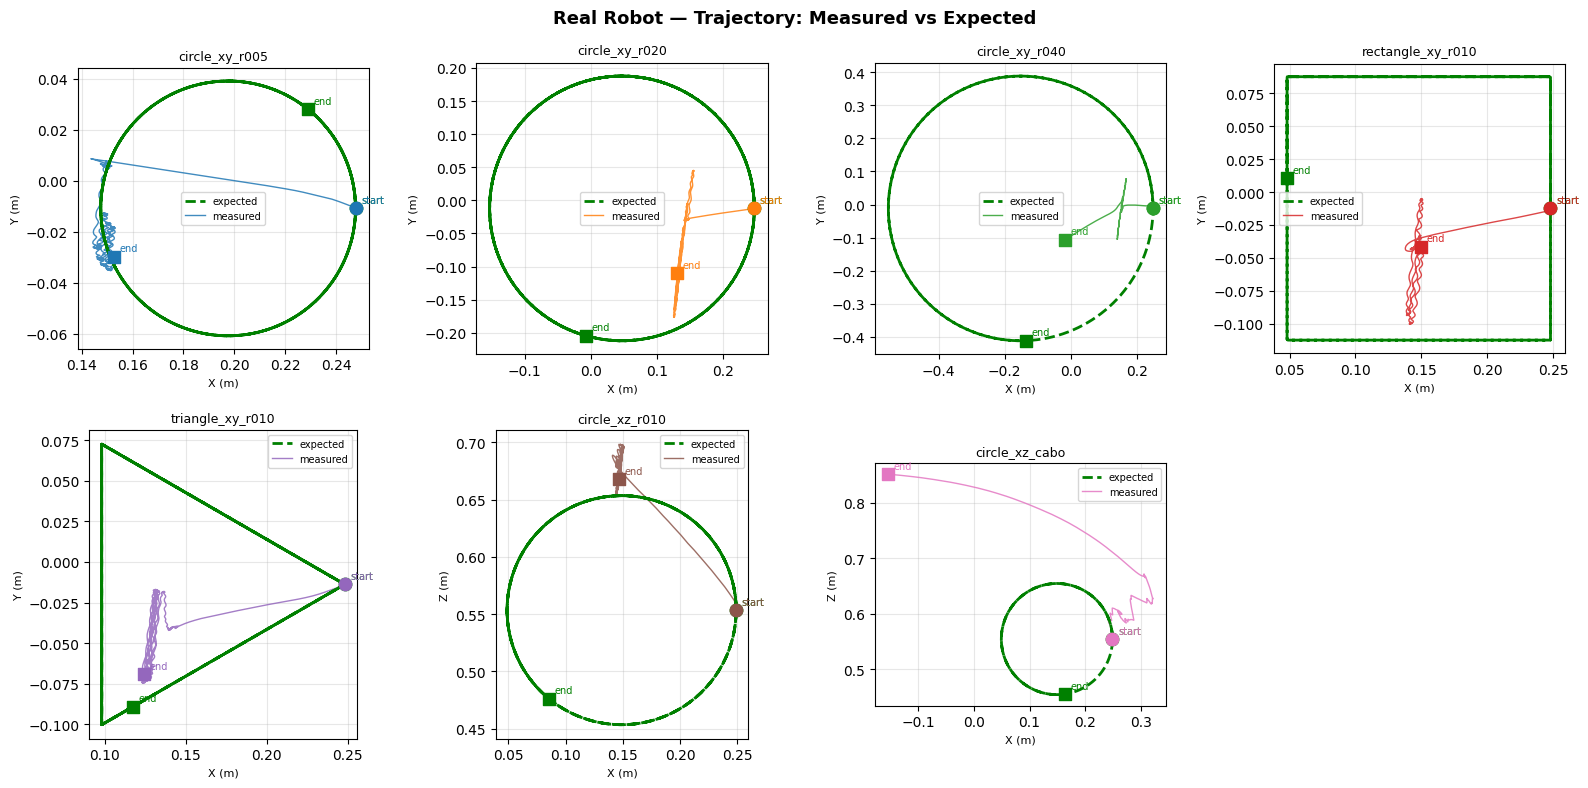

In [98]:
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 4))
fig.suptitle("Real Robot — Trajectory: Measured vs Expected", fontsize=13, fontweight="bold")
axes = axes.flatten()

plane_axes = {
    "circle_xy_r005":   ("ee_x_m",   "ee_y_m",   "ee_des_x_m", "ee_des_y_m", "X (m)", "Y (m)"),
    "circle_xy_r020":   ("ee_x_m",   "ee_y_m",   "ee_des_x_m", "ee_des_y_m", "X (m)", "Y (m)"),
    "circle_xy_r040":   ("ee_x_m",   "ee_y_m",   "ee_des_x_m", "ee_des_y_m", "X (m)", "Y (m)"),
    "rectangle_xy_r010":   ("ee_x_m",   "ee_y_m",   "ee_des_x_m", "ee_des_y_m", "X (m)", "Y (m)"),
    "triangle_xy_r010": ("ee_x_m",   "ee_y_m",   "ee_des_x_m", "ee_des_y_m", "X (m)", "Y (m)"),
    "circle_xz_r010":        ("ee_x_m",   "ee_z_m",   "ee_des_x_m", "ee_des_z_m", "X (m)", "Z (m)"),
    "circle_xz_cabo":        ("ee_x_m",   "ee_z_m",   "ee_des_x_m", "ee_des_z_m", "X (m)", "Z (m)"),
}

def mark_start_end(ax, x_series, y_series, color):
    ax.scatter(x_series.iloc[0],  y_series.iloc[0],  marker="o", s=80,
               color=color, zorder=6, label="_nolegend_")
    ax.scatter(x_series.iloc[-1], y_series.iloc[-1], marker="s", s=80,
               color=color, zorder=6, label="_nolegend_")
    ax.annotate("start", (x_series.iloc[0],  y_series.iloc[0]),
                fontsize=7, color=color, xytext=(4, 4), textcoords="offset points")
    ax.annotate("end",   (x_series.iloc[-1], y_series.iloc[-1]),
                fontsize=7, color=color, xytext=(4, 4), textcoords="offset points")

for i, (name, df) in enumerate(real_tests.items()):
    ax = axes[i]
    ee_a, ee_b, des_a, des_b, xlabel, ylabel = plane_axes[name]

    ax.plot(df[des_a], df[des_b], "g--", linewidth=2.0, label="expected", zorder=3)
    ax.plot(df[ee_a],  df[ee_b],  color=cmap[i], linewidth=1.0, alpha=0.85, label="measured")
    mark_start_end(ax, df[des_a], df[des_b], "green")
    mark_start_end(ax, df[ee_a],  df[ee_b],  cmap[i])

    ax.set_xlabel(xlabel, fontsize=8)
    ax.set_ylabel(ylabel, fontsize=8)
    ax.set_title(name, fontsize=9)
    ax.legend(fontsize=7)
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.3)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

### 7.3 — Summary statistics

In [100]:
RAMP_SKIP_S = 5.0  # ignore first 5 s (setpoint ramp-up)

rows = []
for name, df in real_tests.items():
    task = df[df["time"] >= RAMP_SKIP_S].copy()
    rows.append({
        "test":                 name,
        "duration (s)":         round(df["time"].iloc[-1], 1),
        "samples (t≥5s)":       len(task),
        "tension mean (N)":     round(task["T_meas_N"].mean(), 2),
        "tension std (N)":      round(task["T_meas_N"].std(), 2),
        "tension bias (N)":     round(task["T_meas_N"].mean() - REAL_TENSION_DESIRED, 2),
        "traj. error mean (m)": round(task["pos_error_m"].mean(), 4),
        "traj. error max (m)":  round(task["pos_error_m"].max(), 4),
    })

pd.DataFrame(rows).set_index("test")

,duration (s),samples (t≥5s),tension mean (N),tension std (N),tension bias (N),traj. error mean (m),traj. error max (m)
test,,,,,,,
circle_xy_r005,38.8,3385,7.85,1.13,-2.15,0.1396,0.1782
circle_xy_r020,43.4,3840,8.09,0.93,-1.91,0.2343,0.3222
circle_xy_r040,19.7,1475,7.69,1.16,-2.31,0.4785,0.7350
rectangle_xy_r010,25.5,2047,7.52,1.31,-2.48,0.1832,0.2532
triangle_xy_r010,43.4,3838,7.78,0.96,-2.22,0.1149,0.1645
circle_xz_r010,34.8,2984,7.64,0.95,-2.36,0.1384,0.2117
circle_xz_cabo,19.9,1489,7.55,1.78,-2.45,0.2048,0.6423


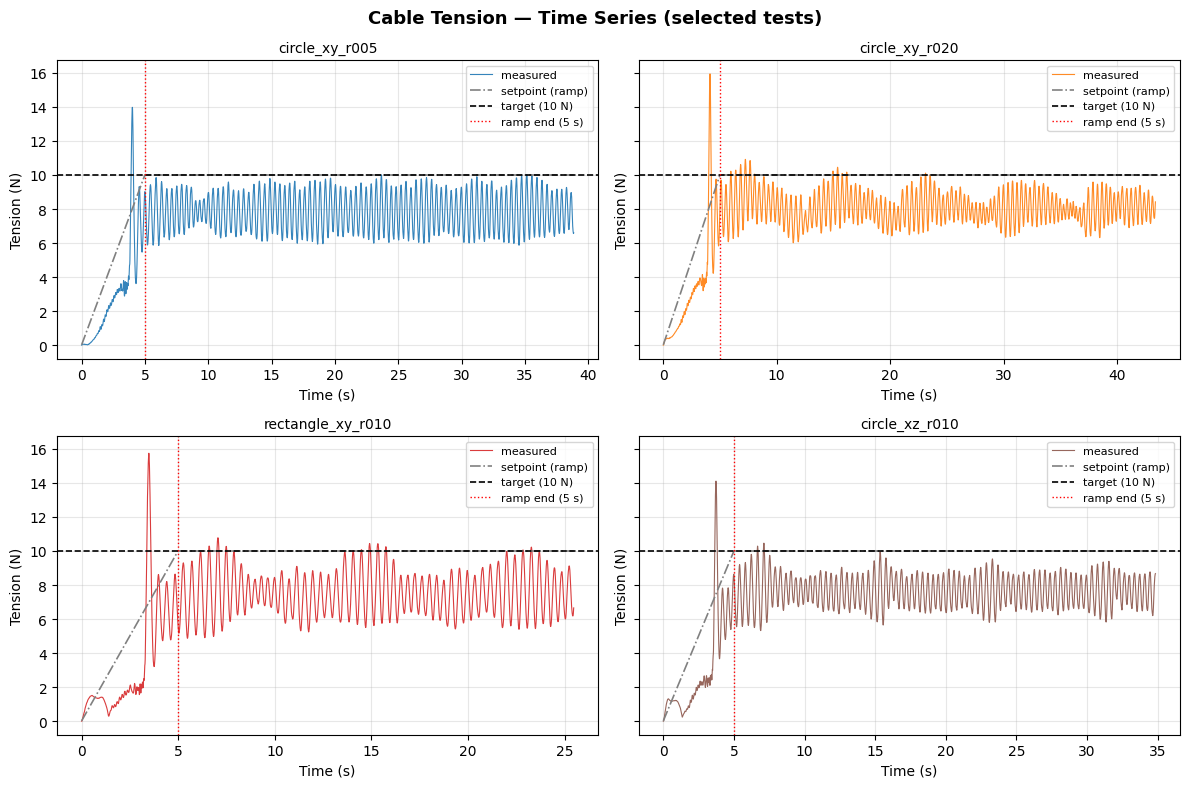

In [101]:
# Focused tension time-series: 4 selected real-robot tests
selected = {
    "circle_xy_r005": real_circle_xy_r005,
    "circle_xy_r020": real_circle_xy_r020,
    "rectangle_xy_r010": real_rectangle_xy_r010,
    "circle_xz_r010":      real_circle_xz_r010,
}

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)
fig.suptitle("Cable Tension — Time Series (selected tests)", fontsize=13, fontweight="bold")
axes = axes.flatten()

for i, (name, df) in enumerate(selected.items()):
    ax = axes[i]
    ax.plot(df["time"], df["T_meas_N"],     linewidth=0.8, alpha=0.9,
            color=cmap[list(real_tests).index(name)], label="measured")
    ax.plot(df["time"], df["T_des_active_N"], linewidth=1.2, linestyle="-.",
            color="gray", label="setpoint (ramp)")
    ax.axhline(REAL_TENSION_DESIRED, color="black", linestyle="--",
               linewidth=1.2, label="target (10 N)")
    ax.axvline(5.0, color="red", linestyle=":", linewidth=1.0, label="ramp end (5 s)")
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Tension (N)")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


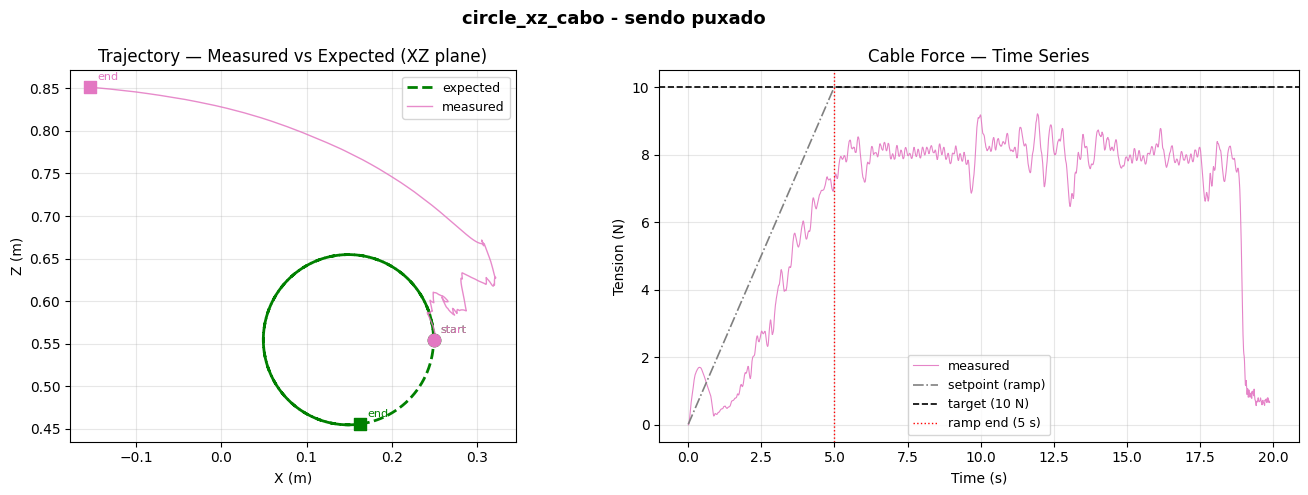

In [102]:
# circle_xz_cabo — trajectory + cable force (1×2)
df = real_circle_xz_cabo
c  = cmap[list(real_tests).index("circle_xz_cabo")]

fig, (ax_traj, ax_force) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("circle_xz_cabo - sendo puxado", fontsize=13, fontweight="bold")

# ── Trajectory ────────────────────────────────────────────────────────────────
ax_traj.plot(df["ee_des_x_m"], df["ee_des_z_m"],
             "g--", linewidth=2.0, label="expected")
ax_traj.plot(df["ee_x_m"],     df["ee_z_m"],
             color=c, linewidth=1.0, alpha=0.85, label="measured")

for x_s, y_s, color in [
    (df["ee_des_x_m"], df["ee_des_z_m"], "green"),
    (df["ee_x_m"],     df["ee_z_m"],     c),
]:
    ax_traj.scatter(x_s.iloc[0],  y_s.iloc[0],  marker="o", s=80, color=color, zorder=6)
    ax_traj.scatter(x_s.iloc[-1], y_s.iloc[-1], marker="s", s=80, color=color, zorder=6)
    ax_traj.annotate("start", (x_s.iloc[0],  y_s.iloc[0]),  fontsize=8,
                     color=color, xytext=(5, 5), textcoords="offset points")
    ax_traj.annotate("end",   (x_s.iloc[-1], y_s.iloc[-1]), fontsize=8,
                     color=color, xytext=(5, 5), textcoords="offset points")

ax_traj.set_xlabel("X (m)")
ax_traj.set_ylabel("Z (m)")
ax_traj.set_title("Trajectory — Measured vs Expected (XZ plane)")
ax_traj.legend(fontsize=9)
ax_traj.set_aspect("equal")
ax_traj.grid(True, alpha=0.3)

# ── Cable force time series ───────────────────────────────────────────────────
ax_force.plot(df["time"], df["T_meas_N"],      linewidth=0.8, alpha=0.9,
              color=c, label="measured")
ax_force.plot(df["time"], df["T_des_active_N"], linewidth=1.2, linestyle="-.",
              color="gray", label="setpoint (ramp)")
ax_force.axhline(REAL_TENSION_DESIRED, color="black", linestyle="--",
                 linewidth=1.2, label="target (10 N)")
ax_force.axvline(5.0, color="red", linestyle=":", linewidth=1.0, label="ramp end (5 s)")
ax_force.set_xlabel("Time (s)")
ax_force.set_ylabel("Tension (N)")
ax_force.set_title("Cable Force — Time Series")
ax_force.legend(fontsize=9)
ax_force.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


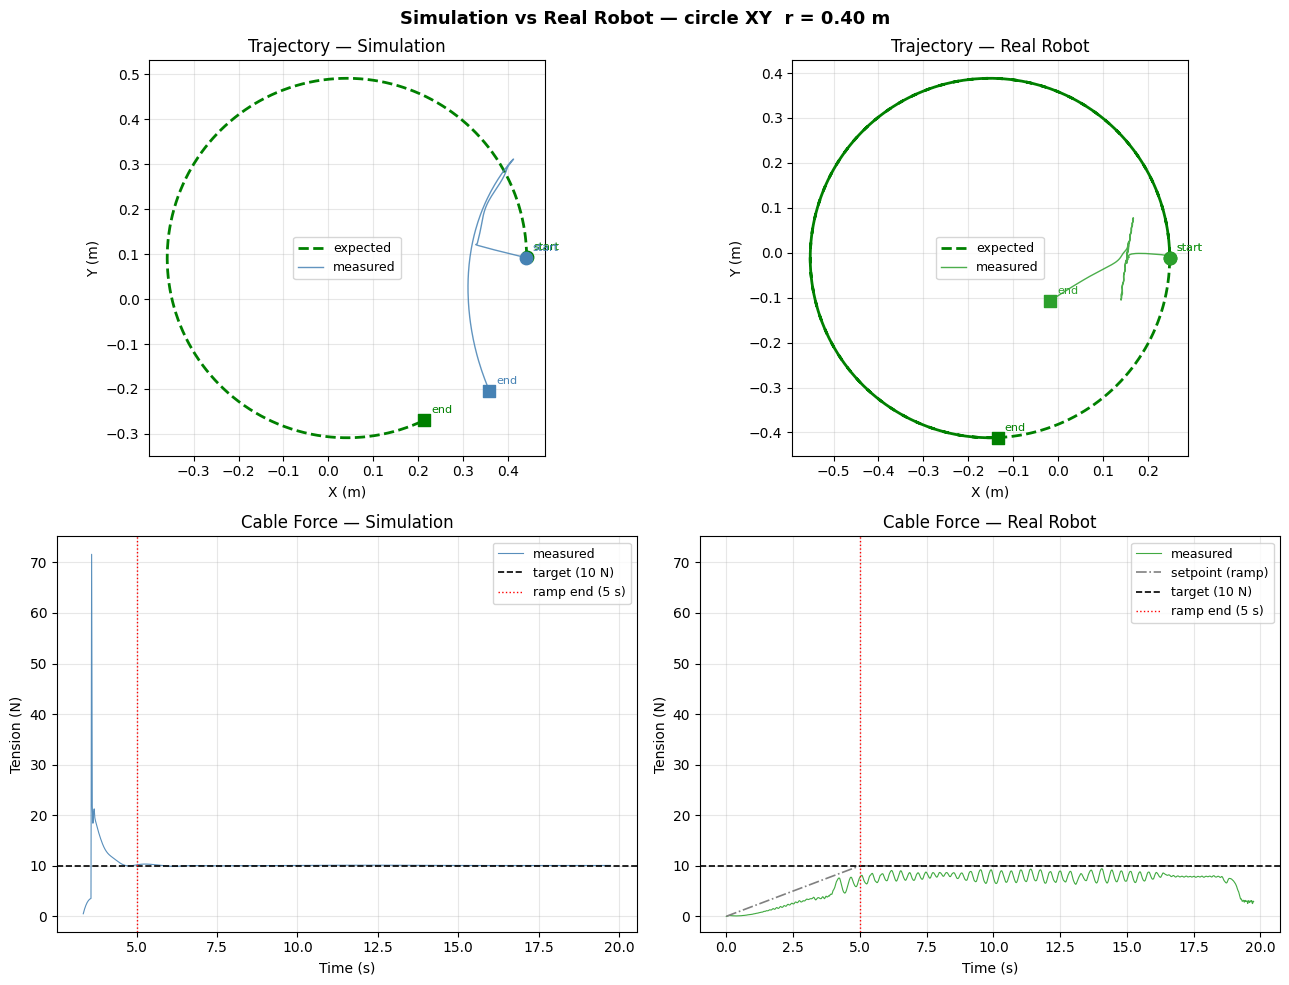

In [103]:
# Simulation vs Real Robot — vertical plane comparison (2×2)
# Sim: circle YZ  r=0.40 m  |  Real: circle XZ  r=0.10 m
# (no YZ real-robot data available — XZ is the closest vertical-plane match)
sim_df  = circle_yz
real_df = real_circle_xz_r010
c_sim   = COLORS["circle_yz"]
c_real  = cmap[list(real_tests).index("circle_xz_r010")]

t_max = min(sim_df["time"].iloc[-1], real_df["time"].iloc[-1])
sim_df  = sim_df[sim_df["time"]   <= t_max].copy()
real_df = real_df[real_df["time"] <= t_max].copy()

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle(
    "Simulation (circle YZ  r=0.40 m)  vs  Real Robot (circle XZ  r=0.10 m)\n"
    "Note: no YZ real-robot data — XZ is the closest vertical-plane match",
    fontsize=11, fontweight="bold"
)
(ax_ts, ax_tr), (ax_fs, ax_fr) = axes

def mark_se(ax, xs, ys, color):
    for xi, yi, lbl in [(xs.iloc[0], ys.iloc[0], "start"), (xs.iloc[-1], ys.iloc[-1], "end")]:
        mk = "o" if lbl == "start" else "s"
        ax.scatter(xi, yi, marker=mk, s=80, color=color, zorder=6)
        ax.annotate(lbl, (xi, yi), fontsize=8, color=color,
                    xytext=(5, 5), textcoords="offset points")

# ── Trajectory — Simulation (YZ plane) ───────────────────────────────────────
# tgt_z not logged → use ee_z as reference for Z axis
ax_ts.plot(sim_df["tgt_y"], sim_df["ee_z"],  "g--", linewidth=2.0, label="expected (tgt_y / ee_z*)")
ax_ts.plot(sim_df["ee_y"],  sim_df["ee_z"],  color=c_sim, linewidth=1.0, alpha=0.85, label="measured")
mark_se(ax_ts, sim_df["tgt_y"], sim_df["ee_z"], "green")
mark_se(ax_ts, sim_df["ee_y"],  sim_df["ee_z"], c_sim)
ax_ts.set_xlabel("Y (m)"); ax_ts.set_ylabel("Z (m)")
ax_ts.set_title("Trajectory — Simulation (YZ)\n* tgt_z not logged")
ax_ts.set_aspect("equal"); ax_ts.legend(fontsize=9); ax_ts.grid(True, alpha=0.3)

# ── Trajectory — Real Robot (XZ plane) ───────────────────────────────────────
ax_tr.plot(real_df["ee_des_x_m"], real_df["ee_des_z_m"], "g--", linewidth=2.0, label="expected")
ax_tr.plot(real_df["ee_x_m"],     real_df["ee_z_m"],     color=c_real, linewidth=1.0, alpha=0.85, label="measured")
mark_se(ax_tr, real_df["ee_des_x_m"], real_df["ee_des_z_m"], "green")
mark_se(ax_tr, real_df["ee_x_m"],     real_df["ee_z_m"],     c_real)
ax_tr.set_xlabel("X (m)"); ax_tr.set_ylabel("Z (m)")
ax_tr.set_title("Trajectory — Real Robot (XZ)")
ax_tr.set_aspect("equal"); ax_tr.legend(fontsize=9); ax_tr.grid(True, alpha=0.3)

# ── Force — Simulation ────────────────────────────────────────────────────────
ax_fs.plot(sim_df["time"], sim_df["tension_N"], color=c_sim, linewidth=0.8, alpha=0.9, label="measured")
ax_fs.axhline(TENSION_DESIRED, color="black", linestyle="--", linewidth=1.2, label="target (10 N)")
ax_fs.axvline(5.0, color="red", linestyle=":", linewidth=1.0, label="ramp end (5 s)")
ax_fs.set_xlabel("Time (s)"); ax_fs.set_ylabel("Tension (N)")
ax_fs.set_title("Cable Force — Simulation")
ax_fs.legend(fontsize=9); ax_fs.grid(True, alpha=0.3)

# ── Force — Real Robot ────────────────────────────────────────────────────────
ax_fr.plot(real_df["time"], real_df["T_meas_N"],       color=c_real, linewidth=0.8, alpha=0.9, label="measured")
ax_fr.plot(real_df["time"], real_df["T_des_active_N"], color="gray",  linewidth=1.2, linestyle="-.", label="setpoint (ramp)")
ax_fr.axhline(REAL_TENSION_DESIRED, color="black", linestyle="--", linewidth=1.2, label="target (10 N)")
ax_fr.axvline(5.0, color="red", linestyle=":", linewidth=1.0, label="ramp end (5 s)")
ax_fr.set_xlabel("Time (s)"); ax_fr.set_ylabel("Tension (N)")
ax_fr.set_title("Cable Force — Real Robot")
ax_fr.legend(fontsize=9); ax_fr.grid(True, alpha=0.3)

y_min = min(ax_fs.get_ylim()[0], ax_fr.get_ylim()[0])
y_max = max(ax_fs.get_ylim()[1], ax_fr.get_ylim()[1])
ax_fs.set_ylim(y_min, y_max)
ax_fr.set_ylim(y_min, y_max)

plt.tight_layout()
plt.show()
